In [1]:
!pip install sentence-transformers umap-learn scikit-learn tqdm



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
import umap.umap_ as umap


In [3]:
#Load Dataset
path = r"C:\Users\natra\OneDrive\Documents\NLP Project\dataset\indian_supreme_court_judgments.csv"
df = pd.read_csv(path)

print("Columns:", df.columns)
df.head(2)


Columns: Index(['id', 'petitioner', 'respondent', 'date_of_judgment', 'bench', 'act',
       'headnote', 'citations', 'judgment_text', 'raw_text'],
      dtype='object')


,id,petitioner,respondent,date_of_judgment,bench,act,headnote,citations,judgment_text,raw_text
0,5-2021_MA-000083-2021,the Government of India,the,2020-01-09,NaN,NaN,background in which the above applications hav...,NaN,Non-Reportable IN THE SUPREME COURT OF INDIA C...,Non-Reportable IN THE SUPREME COURT OF INDIA C...
1,28-2021_C.A.No.-000867-000867-2021,the Directorate of Medical Education & People’...,Appeals & Niyam & the State of Madhya Pradesh,2021-03-02,NaN,NaN,NaN,Ors. v. Medical; Ors. v. State; Ors. v. State;...,Reportable IN THE SUPREME COURT OF INDIA CIVIL...,Reportable IN THE SUPREME COURT OF INDIA CIVIL...


In [5]:
#Clean Legal Text
def clean_indian_legal_text(text):
    if pd.isna(text):
        return ""

    text = str(text)

    text = re.sub(r'IN THE .*? COURT OF INDIA', ' ', text, flags=re.I)
    text = re.sub(r'\b[A-Z]*\s?No\.?\s?\d+\/?\d*\b', ' ', text)
    text = re.sub(r'\(\d{4}\).*?\d+', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)

    return text.strip()


df["clean_text"] = df["raw_text"].astype(str).apply(clean_indian_legal_text)

df["clean_text"].iloc[0][:300]


'Non Reportable CIVIL APPELLATE JURISDICTION M A of 2021 In M A Diary of 2020 In Civil Appeal Nos 6328 6399 of 2015 Union of India Applicant s Versus Association of Unified Telecom Service Providers of India and Ors Respondent s With M A of 2021 In M A Diary of 2020 In Civil Appeal of 2015 M A of 202'

In [7]:
#Load Transformer Model
model = SentenceTransformer('all-MiniLM-L6-v2')


C:\Users\natra\anaconda3\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [9]:
#Generate Embeddings (Baseline)
# Optional sampling for large dataset
sample_size = min(len(df), 2000)
df = df.sample(sample_size, random_state=42)

texts = df["clean_text"].tolist()

baseline_embeddings = model.encode(
    texts,
    batch_size=16,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Embedding shape:", baseline_embeddings.shape)


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Embedding shape: (500, 384)


In [11]:
#Similarity Matrix
baseline_similarity = cosine_similarity(baseline_embeddings)


In [13]:
#Clustering
num_clusters = 10

kmeans = KMeans(n_clusters=num_clusters, random_state=42)
df["baseline_cluster"] = kmeans.fit_predict(baseline_embeddings)

df[["id", "baseline_cluster"]].head()


,id,baseline_cluster
361,13828-2019_C.A.No.-000814-000815-2021,5
73,2390-2020_C.A.No.-005685-005685-2021,4
374,14346-2018_Crl.A.No.-001216-001216-2019,3
155,5445-2014_W.P.(C)No.-000229-000229-2014,2
104,3598-2021_Crl.A.No.-001043-001043-2021,3


C:\Users\natra\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


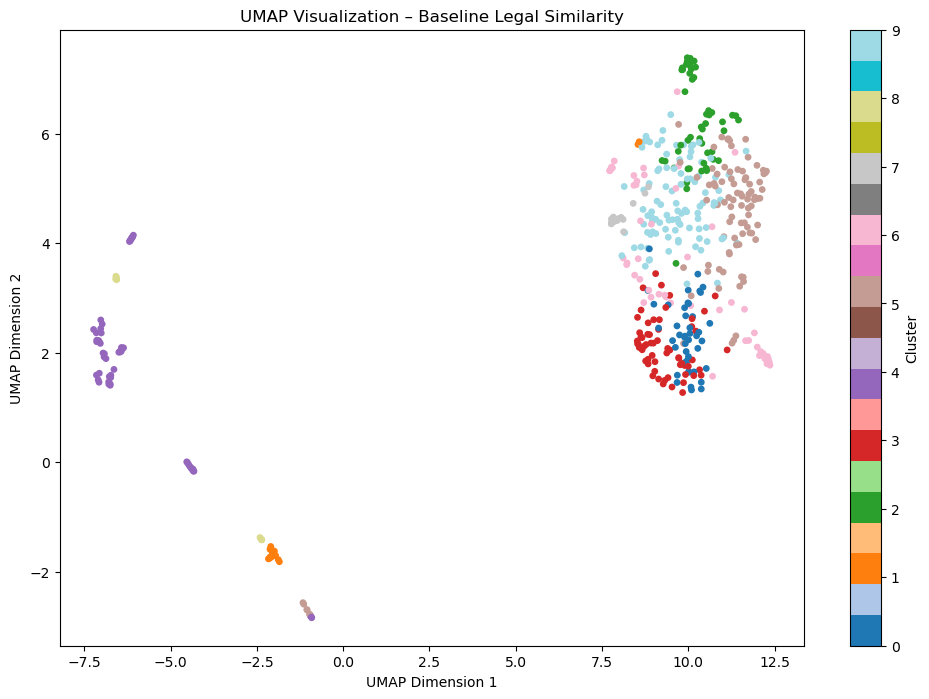

In [15]:
#UMAP Visualization
reducer = umap.UMAP(random_state=42)
embedding_2d = reducer.fit_transform(baseline_embeddings)

plt.figure(figsize=(12,8))
scatter = plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=df["baseline_cluster"],
    cmap="tab20",
    s=15
)

plt.title("UMAP Visualization – Baseline Legal Similarity")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.colorbar(scatter, label="Cluster")
plt.show()


In [17]:
#Similar Case Search
def baseline_find_similar(index, top_k=5):

    scores = baseline_similarity[index]
    top_idx = np.argsort(scores)[::-1][1:top_k+1]

    print("="*80)
    print("QUERY CASE")
    print("="*80)
    print("ID:", df.iloc[index]["id"])
    print("\nTEXT PREVIEW:\n", df.iloc[index]["clean_text"][:300])

    print("\n\nSIMILAR CASES")
    print("="*80)

    for i in top_idx:
        print("\n----------------------------------")
        print("ID:", df.iloc[i]["id"])
        print("Similarity:", round(float(scores[i]), 3))
        print("Preview:", df.iloc[i]["clean_text"][:200])


In [19]:
baseline_find_similar(0)


QUERY CASE
ID: 13828-2019_C.A.No.-000814-000815-2021

TEXT PREVIEW:
 1 REPORTABLE CIVIL APPELLATE JURISDICTION CIVIL APPEAL NOS 814 815 Of 2021 arising out of SLP C Nos 11009 11010 of 2019 MADAN MOHAN SINGH APPELLANT S VERSUS VED PRAKASH ARYA RESPONDENT S J U D G M E N T ASHOK BHUSHAN J Leave granted 2 These appeals have been filed by the appellant challenging the ju


SIMILAR CASES

----------------------------------
ID: 7506-2017_C.A.No.-005738-005739-2021
Similarity: 0.809
Preview: REPORTABLE CIVIL APPELLATE JURISDICTION CIVIL APPEAL NOS 5738 5739 OF 2021 Ajai Pal Singh Ors Appellant s Versus State of Uttar Pradesh Anr Respondent s WITH CIVIL APPEAL NO 5740 OF 2021 Smt Barfi Dev

----------------------------------
ID: 18274-2009_C.A.No.-002153-002153-2012
Similarity: 0.8
Preview: REPORTABLE CIVIL APPELLATE JURISDICTION CIVIL APPEAL NO 2153 OF 2 012 State of M P Appellant versus Ghisilal Respondent J U D G M E N T R SUBHASH REDDY J 1 This Civil Appeal is preferred by the appell

----

In [21]:
#Search for NEW Unseen Case
def baseline_search_new_case(new_text, top_k=5):

    cleaned = clean_indian_legal_text(new_text)

    new_embedding = model.encode([cleaned], convert_to_numpy=True)

    scores = cosine_similarity(new_embedding, baseline_embeddings)[0]
    top_idx = np.argsort(scores)[::-1][:top_k]

    print("="*80)
    print("NEW CASE INPUT")
    print("="*80)
    print(cleaned[:300])

    print("\n\nMOST SIMILAR EXISTING CASES (Baseline)")
    print("="*80)

    for i in top_idx:
        print("\n----------------------------------")
        print("ID:", df.iloc[i]["id"])
        print("Similarity:", round(float(scores[i]), 3))
        print("Preview:", df.iloc[i]["clean_text"][:200])


In [23]:
#Test Baseline Model 
new_case_text = """
The present appeal arises from a motor vehicle accident claim.
The claimant suffered serious injuries due to rash and negligent driving.
Compensation awarded by the tribunal is challenged as inadequate.
The appellant seeks enhancement of compensation.
"""
baseline_search_new_case(new_case_text)


NEW CASE INPUT
The present appeal arises from a motor vehicle accident claim The claimant suffered serious injuries due to rash and negligent driving Compensation awarded by the tribunal is challenged as inadequate The appellant seeks enhancement of compensation


MOST SIMILAR EXISTING CASES (Baseline)

----------------------------------
ID: 9247-2021_C.A.No.-005926-005926-2021
Similarity: 0.74
Preview: CA 5926 2021 1 Reportable CIVIL APPELLATE JURISDICTION Civil Appeal of 2021 Arising out of SLP C of 2021 Satya Prakash Dwivedi Appellant Versus Munna alias Chandrabhan Yadav Respondent and Others J U 

----------------------------------
ID: 7071-2020_C.A.No.-004800-004800-2021
Similarity: 0.693
Preview: REPORTABLE CIVIL APPELLATE JURISDICTION CIVIL APPEAL NO 4800 OF 2021 arising out of SLP C of 2021 The Oriental Insurance Company Limited APPELLANT S VERSUS Kahlon Jasmail Singh Kahlon deceased through

----------------------------------
ID: 9787-2021_C.A.No.-004476-004477-2021
Similarity

In [ ]:
The present appeal arises from a motor vehicle accident claim.
The claimant suffered serious injuries due to rash and negligent driving.
Compensation awarded by the tribunal is challenged as inadequate.
The appellant seeks enhancement of compensation.

In [ ]:
The present appeal arises under Section 166 of the Motor Vehicles Act, 1988.
The claimant sustained permanent disability due to a road traffic accident.
The Motor Accident Claims Tribunal awarded compensation, which the appellant
contends is insufficient. The appeal seeks enhancement of compensation
along with interest under the provisions of the Motor Vehicles Act.

In [ ]:
The present appeal arises from a motor vehicle accident claim.
The claimant suffered serious injuries due to rash and negligent driving.
Compensation awarded by the tribunal is challenged as inadequate.
The appellant seeks enhancement of compensation.